# MIE1517 Project: Skin Cancer Classification

## Brief Summary:  
* Data Collection:
  All data that our project required to train, validate, and test are collected and are ready to be loaded & processed.  
  The data for training, validation and, model evaluation are:  
  >[ISIC_2024_Training_Input](https://doi.org/10.34970/2024-slice-3d) (features),   
  >[ISIC_2024_Training_GroundTruth](https://doi.org/10.34970/2024-slice-3d) (targets),   
  >[ISIC_2024_Training_Supplement.csv](https://doi.org/10.34970/2024-slice-3d).    

  The data for final testing are
  >[ISIC2018_Task3_Training_Input](https://challenge.isic-archive.com/data/#2018) (features),  
  >[ISIC2018_Task3_Training_GroundTruth](https://challenge.isic-archive.com/data/#2018) (targets).

* Result Achieved: The current best model achieve the following:  
  Accuracy = 0.82  
  AUC-ROC = 0.875  
  F1 Score = 0.0085,
  
  with the following hyperparameter settings:  
  learning rate = 0.01  
  weight decay (optimizer) = 0.001  
  dropout (HybridDenseNetEfficientNet) = 0.4





## Future Development:
* The model archetecture can still be modified and fine-tuned.
* The current model only predict whether a case is belign or malignant.  
The dataset for training has very few malignant data points, we would expect an improvement in accuracy once a model is built to predict the class of lesions as well.

In [ ]:
# Unzip input images
_ = !unzip -q "/content/ISIC_2024_Training_Input" -d "/content/"

: 

In [1]:
# Import Necessary Libraries
import os
import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models
import torchvision.transforms as T

from sklearn.model_selection import train_test_split, ParameterSampler
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm

# Reproducibility
SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cpu


## Configuration

In [9]:
# MACRO Configurations (Global Variables and Hyperparameters)
# ── Paths ──────────────────────────────────────────────────────────────────
ROOT          = Path(".")
IMAGE_DIR     = ROOT / "ISIC_2024_Training_Input"
GT_CSV        = ROOT / "train" / "ISIC_2024_Training_GroundTruth.csv"

# ── Data split ratios ──────────────────────────────────────────────────────
TRAIN_RATIO = 0.60
VAL_RATIO   = 0.20   # remaining 0.20 goes to test

# ── Image settings ─────────────────────────────────────────────────────────
IMAGE_SIZE  = 224    # unified input size for both backbones

# ── Training hyperparameters ───────────────────────────────────────────────
BATCH_SIZE  = 32
NUM_EPOCHS  = 10
LR          = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT     = 0.4
# NOTE: On Windows in a Jupyter notebook, num_workers > 0 causes worker
# processes to re-import __main__, leading to a spawn deadlock before the
# first batch is served. Keep this at 0 for notebook environments on Windows.
NUM_WORKERS = 0

# ── Optional: use a fraction of data for fast iteration (1.0 = full dataset)
SAMPLE_FRACTION = 1.0


# [Part A] Predict Benign / Maglinant Case
The objective of this part is to predict whether a case is benign or malignant using the ISIC 2024 Skin Lesion dataset. Each sample consists of a dermoscopic image paired with structured patient metadata, and is labeled as either benign (0) or malignant (1).

Skin cancer is one of the most common cancers worldwide, and early detection is critical for improving patient outcomes. Malignant melanoma in particular can be life-threatening if not caught early, yet it is highly treatable when identified at an early stage. Automated classification systems can assist dermatologist by flagging high-risk lesions for further examination, reducing diagnostic workload and improving consistency. This is a binary classification task with a significant class imbalance — malignant cases are far less frequent than benign ones. As a result, standard accuracy is a poor performance metric. Instead, we use AUROC (Area Under the Receiver Operating Characteristic Curve) as the primary evaluation metric, which measures the model's ability to rank malignant cases above benign ones regardless of the classification threshold. 

Our approach involves the following steps: 
1. **Data loading and exploration** — load images and ground truth labels, examine class distribution, and identify imbalance. 
2. **Preprocessing** — resize and normalize images, encode metadata features, and apply data augmentation to the minority class. 
3. **Model training** — train a binary classifier and tune the decision threshold to balance sensitivity and specificity. 
4. **Evaluation** — report AUROC, confusion matrix, and per-class metrics on 
   the validation set.

## Data Loading & Exploratory Analysis

Total samples with images: 401,059

Class distribution:
malignant
Benign       400666
Malignant       393
Name: count, dtype: int64


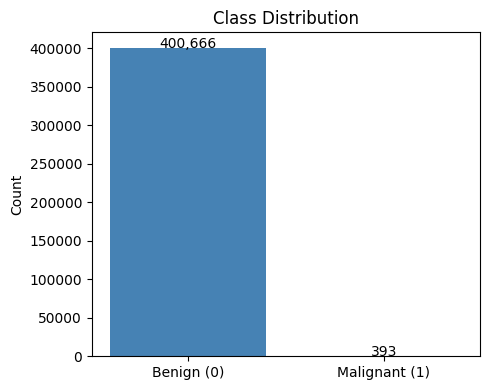

In [10]:
# Load ground truth CSV
df = pd.read_csv(GT_CSV)
df["malignant"] = df["malignant"].astype(int)

# Keep only rows whose image file actually exists
df["img_path"] = df["isic_id"].apply(lambda x: IMAGE_DIR / f"{x}.jpg")
df = df[df["img_path"].apply(lambda p: p.exists())].reset_index(drop=True)

print(f"Total samples with images: {len(df):,}")
print(f"\nClass distribution:")
print(df["malignant"].value_counts().rename({0: "Benign", 1: "Malignant"}))

# Optional: sub-sample for faster iteration
if SAMPLE_FRACTION < 1.0:
    df = df.groupby("malignant", group_keys=False).apply(
        lambda g: g.sample(frac=SAMPLE_FRACTION, random_state=SEED)
    ).reset_index(drop=True)
    print(f"\nAfter sampling ({SAMPLE_FRACTION:.0%}): {len(df):,} samples")

# ── Class balance plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["malignant"].value_counts().sort_index()
ax.bar(["Benign (0)", "Malignant (1)"], counts.values, color=["steelblue", "tomato"])
ax.set_ylabel("Count")
ax.set_title("Class Distribution")
for i, v in enumerate(counts.values):
    ax.text(i, v + 200, f"{v:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()


## Dataset Class

In [11]:
# Define Dataset Class
class SkinLesionDataset(Dataset):
    """
    Loads TBP-cropped lesion images by isic_id and returns
    (image_tensor, label) pairs.
    """
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row["img_path"]).convert("RGB")
        label = torch.tensor(row["malignant"], dtype=torch.float32)
        if self.transform:
            image = self.transform(image)
        return image, label


## Train / Validation / Test Split  (60 : 20 : 20)

In [12]:
# Stratified Training / Validation / Test set load and split
# Step 1: 60% train, 40% temp
df_train, df_temp = train_test_split(
    df, test_size=(1 - TRAIN_RATIO), stratify=df["malignant"], random_state=SEED
)
# Step 2: 50/50 val & test from temp
df_val, df_test = train_test_split(
    df_temp, test_size=0.5, stratify=df_temp["malignant"], random_state=SEED
)

print(f"Train : {len(df_train):>7,}  "
      f"({df_train['malignant'].mean()*100:.1f}% malignant)")
print(f"Val   : {len(df_val):>7,}  "
      f"({df_val['malignant'].mean()*100:.1f}% malignant)")
print(f"Test  : {len(df_test):>7,}  "
      f"({df_test['malignant'].mean()*100:.1f}% malignant)")

# ── Transforms ────────────────────────────────────────────────────────────
# ImageNet normalisation used by both DenseNet and EfficientNet pretrained weights
_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    T.RandomCrop(IMAGE_SIZE),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.RandomRotation(20),
    T.ToTensor(),
    T.Normalize(_MEAN, _STD),
])

eval_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(_MEAN, _STD),
])

# ── Datasets ──────────────────────────────────────────────────────────────
train_dataset = SkinLesionDataset(df_train, transform=train_transform)
val_dataset   = SkinLesionDataset(df_val,   transform=eval_transform)
test_dataset  = SkinLesionDataset(df_test,  transform=eval_transform)

# ── Weighted sampler to handle class imbalance in training ─────────────────
n_benign    = (df_train["malignant"] == 0).sum()
n_malignant = (df_train["malignant"] == 1).sum()
class_weights = {0: 1.0 / n_benign, 1: 1.0 / n_malignant}
sample_weights = df_train["malignant"].map(class_weights).values
sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

# ── DataLoaders ────────────────────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
    num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f"\nDataLoaders ready. "
      f"Train batches: {len(train_loader)}, "
      f"Val batches: {len(val_loader)}, "
      f"Test batches: {len(test_loader)}")


Train : 240,635  (0.1% malignant)
Val   :  80,212  (0.1% malignant)
Test  :  80,212  (0.1% malignant)

DataLoaders ready. Train batches: 7520, Val batches: 2507, Test batches: 2507


c:\Users\Perry\anaconda3\envs\mie1517proj\Lib\site-packages\torch\utils\data\sampler.py:264: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  weights_tensor = torch.as_tensor(weights, dtype=torch.double)


## Hybrid DenseNet + EfficientNet Model

The architecture runs two CNN branches in parallel on the same input image:
- **DenseNet-121 branch** — dense connectivity promotes fine-grained texture reuse (output: 1024-d)
- **EfficientNet-B4 branch** — compound scaling captures multi-scale patterns efficiently (output: 1792-d)

Both feature vectors are concatenated (2816-d) and passed through a fusion MLP for binary classification.

In [13]:
# Define Hybrid CNN Model
class HybridDenseNetEfficientNet(nn.Module):
    """
    Hybrid CNN:
      - DenseNet-121  → fine-grained texture features (1024-d)
      - EfficientNet-B4 → multi-scale pattern features  (1792-d)
    Features are concatenated then fed into a fusion classifier.
    """

    # Output feature dimensions of the chosen backbone variants
    _DENSENET_OUT    = 1024
    _EFFICIENTNET_OUT = 1792    # B4_OUT

    def __init__(self, dropout: float = DROPOUT, freeze_backbone1: bool = False, freeze_backbone2: bool = False):
        super().__init__()

        # ── DenseNet-121 backbone ──────────────────────────────────────────
        densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        self.densenet_features = densenet.features        # conv layers
        self.densenet_pool     = nn.AdaptiveAvgPool2d((1, 1))

        # ── EfficientNet-B4 backbone ───────────────────────────────────────
        efficientnet = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.DEFAULT)
        self.efficientnet_features = efficientnet.features
        self.efficientnet_pool     = nn.AdaptiveAvgPool2d((1, 1))

        # ── Optional backbone freezing (for initial warm-up) ────────
        if freeze_backbone1:
            for param in self.densenet_features.parameters():
                param.requires_grad = False
        if freeze_backbone2:
            for param in self.efficientnet_features.parameters():
                param.requires_grad = False

        # ── Fusion classifier ─────────────────────────────────────────────
        combined_dim = self._DENSENET_OUT + self._EFFICIENTNET_OUT  # 2816 total output dim
        # Classifier after the combined model
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(combined_dim),
            nn.Dropout(dropout),
            nn.Linear(combined_dim, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),
            nn.Linear(512, 1),   # raw logit for BCEWithLogitsLoss
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # DenseNet branch
        d = self.densenet_features(x)
        d = self.densenet_pool(d)
        d = torch.flatten(d, 1)                          # (B, 1024)

        # EfficientNet branch
        e = self.efficientnet_features(x)
        e = self.efficientnet_pool(e)
        e = torch.flatten(e, 1)                          # (B, 1792)

        # Feature fusion → classification
        fused = torch.cat([d, e], dim=1)                 # (B, 2816)
        return self.classifier(fused).squeeze(1)         # (B,)


# ── Instantiate & inspect ─────────────────────────────────────────────────
model = HybridDenseNetEfficientNet(dropout=DROPOUT).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to C:\Users\Perry/.cache\torch\hub\checkpoints\densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 56.6MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to C:\Users\Perry/.cache\torch\hub\checkpoints\efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:01<00:00, 69.7MB/s]


Total parameters    : 25,950,921
Trainable parameters: 25,950,921


## Training Setup

In [14]:

# ── Loss: pos_weight compensates for class imbalance ─────────────────────
pos_weight = torch.tensor([n_benign / n_malignant], dtype=torch.float32).to(DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ── Optimiser: AdamW with weight decay ────────────────────────────────────
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ── LR scheduler: cosine annealing over all epochs ────────────────────────
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# ── Mixed-precision scaler (only on GPU) ─────────────────────────────────
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

print(f"pos_weight for BCEWithLogitsLoss: {pos_weight.item():.2f}")


pos_weight for BCEWithLogitsLoss: 1018.64


C:\Users\Perry\AppData\Local\Temp\ipykernel_29332\244692834.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))


## Training Loop

In [15]:
# Define the training loop function
def run_epoch(model, loader, criterion, optimizer=None, scaler=None,
              device=DEVICE, desc="", use_cached=False):
    """
    Run one epoch of training or evaluation.
    When optimizer is None, runs in eval mode (no gradient updates).
    Returns: (avg_loss, auc_roc)
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss   = 0.0
    running_loss = 0.0
    all_labels, all_probs = [], []

    pbar = tqdm(loader, desc=desc, leave=False,
                bar_format="{l_bar}{bar:30}{r_bar}")

    with torch.set_grad_enabled(is_train):
        for batch_idx, (images, labels) in enumerate(pbar):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast('cuda', enabled=(device.type == "cuda")):
                if use_cached:
                    logits = model.classifier(images).squeeze(1)
                else:
                    logits = model(images)
                loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            batch_loss    = loss.item()
            total_loss   += batch_loss * images.size(0)
            running_loss  = total_loss / ((batch_idx + 1) * images.size(0))

            probs = torch.sigmoid(logits).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())

            pbar.set_postfix(loss=f"{running_loss:.4f}")

    avg_loss = total_loss / len(loader.dataset)
    auc      = roc_auc_score(all_labels, all_probs)
    return avg_loss, auc


## (Before Hyperparameter tuning - Extract features from the pretrained nets)

    * This speed up the hyperparameter tuning process

In [16]:
def extract_features(model, dataloader, device, save_path):
    """Run images through frozen backbones once and save features to disk."""
    model.eval()
    all_d, all_e, all_labels = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f"Extracting {save_path}"):
            images = images.to(device, non_blocking=True)

            # DenseNet branch
            d = model.densenet_features(images)
            d = model.densenet_pool(d)
            d = torch.flatten(d, 1)             # (B, 1024)

            # EfficientNet branch
            e = model.efficientnet_features(images)
            e = model.efficientnet_pool(e)
            e = torch.flatten(e, 1)             # (B, 1792)

            all_d.append(d.cpu())
            all_e.append(e.cpu())
            all_labels.append(labels.cpu())

    torch.save({
        "densenet":     torch.cat(all_d),        # (N, 1024)
        "efficientnet": torch.cat(all_e),        # (N, 1792)
        "labels":       torch.cat(all_labels),   # (N,)
    }, save_path)
    print(f"Saved {torch.cat(all_d).shape[0]:,} samples to {save_path}")

In [17]:
class CachedFeatureDataset(Dataset):
    """Serves pre-extracted (densenet, efficientnet) feature pairs + labels."""
    def __init__(self, path):
        data             = torch.load(path)
        d_feats     = data["densenet"]       # (N, 1024)
        e_feats     = data["efficientnet"]   # (N, 1792)
        self.fused   = torch.cat([d_feats, e_feats], dim=1)  # (N, 2816)
        self.labels      = data["labels"]         # (N,)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.fused[idx], self.labels[idx]

In [18]:
# extract features
extract_model = HybridDenseNetEfficientNet(
    freeze_backbone1=True,
    freeze_backbone2=True,
).to(DEVICE)

extract_features(extract_model, train_loader, DEVICE, "train_feats.pt")
extract_features(extract_model, val_loader,   DEVICE, "val_feats.pt")
del extract_model  # free GPU memory

# Build cached loaders
feat_train_loader = DataLoader(
    CachedFeatureDataset("train_feats.pt"),
    batch_size=1024, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True
)
feat_val_loader = DataLoader(
    CachedFeatureDataset("val_feats.pt"),
    batch_size=1024, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)

c:\Users\Perry\anaconda3\envs\mie1517proj\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Extracting train_feats.pt:   0%|          | 0/7520 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Hyperparameter Tuning

In [ ]:
# Hyperparameter Settings

TRIAL_EPOCHS = 3
N_TRIALS     = 10
param_grid = {
    "LR":           [0.0005, 0.001, 0.005, 0.01],
    "WEIGHT_DECAY": [0.0001, 0.0001, 0.001, 0.01],
    "DROPOUT":      [0.2, 0.3, 0.4, 0.5, 0.6],
}
param_list = list(ParameterSampler(param_grid, n_iter=N_TRIALS, random_state=SEED))
print(f"Running {N_TRIALS} random trials × {TRIAL_EPOCHS} epochs each\n")

In [ ]:
# ── find the best hyperparameters  ────────────────────────────────────

def run_trial(params):
    trial_model = HybridDenseNetEfficientNet(dropout=params["DROPOUT"],
                                             freeze_backbone1=True,
                                             freeze_backbone2=True).to(DEVICE)

    pw = torch.tensor([n_benign / n_malignant], dtype=torch.float32).to(DEVICE)
    trial_crit = nn.BCEWithLogitsLoss(pos_weight=pw)
    trial_optim = optim.AdamW(trial_model.classifier.parameters(), lr=params["LR"], weight_decay=params["WEIGHT_DECAY"])
    trial_sched  = optim.lr_scheduler.CosineAnnealingLR(trial_optim, T_max=TRIAL_EPOCHS, eta_min=1e-6
    )
    trial_scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
    best_val_auc = 0.0

    for epoch in range(TRIAL_EPOCHS):
        run_epoch(trial_model, feat_train_loader, trial_crit, optimizer=trial_optim, scaler=trial_scaler,
                  desc=f"    epoch {epoch+1}/{TRIAL_EPOCHS}",use_cached=1)
        trial_sched.step()

        _, val_auc = run_epoch(trial_model, feat_val_loader, trial_crit,
                               desc=f"    val   {epoch+1}/{TRIAL_EPOCHS}",use_cached=1)

        best_val_auc = max(best_val_auc, val_auc)

    return best_val_auc


tuning_results = []

for i, params in enumerate(param_list):
    val_auc = run_trial(params)

    tuning_results.append({"params": params, "val_auc": val_auc})
    print(f"Trial {i+1:>2}/{N_TRIALS} | AUC: {val_auc:.4f} | "
          f"LR={params['LR']:.4f}  WD={params['WEIGHT_DECAY']:.4f}  "
          f"DROPOUT={params['DROPOUT']}")
tuning_results.sort(key=lambda x: x["val_auc"], reverse=True)
best_params = tuning_results[0]["params"]

In [ ]:
# save best hyperparameters
best_hp_df = pd.DataFrame([best_params])
best_hp_df["val_auc"] = tuning_results[0]["val_auc"]

save_path = ROOT / "best_hyperparameters.csv"
best_hp_df.to_csv(save_path, index=False)
print(best_hp_df.to_string(index=False))

# ── train the model with best hyperparameters  ────────────────────────────────────
model = HybridDenseNetEfficientNet(
    dropout=best_params["DROPOUT"],
    freeze_backbone1=True,
    freeze_backbone2=True,
).to(DEVICE)

pos_weight = torch.tensor([n_benign / n_malignant], dtype=torch.float32).to(DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = optim.AdamW(
    model.parameters(),
    lr=best_params["LR"],
    weight_decay=best_params["WEIGHT_DECAY"],
)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
scaler     = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

# ── Training loop with early stopping ────────────────────────────────────
PATIENCE  = 3
CKPT_PATH = "best_model.pth"

history = {"train_loss": [], "train_auc": [], "val_loss": [], "val_auc": []}
best_val_auc = 0.0
patience_ctr = 0

epoch_pbar = tqdm(range(1, NUM_EPOCHS + 1), desc="Epochs",
                  bar_format="{l_bar}{bar:20}{r_bar}")

for epoch in epoch_pbar:
    tr_loss, tr_auc = run_epoch(
        model, feat_train_loader, criterion, optimizer, scaler,
        desc=f"  Train [{epoch}/{NUM_EPOCHS}]",use_cached=True
    )
    vl_loss, vl_auc = run_epoch(
        model, feat_val_loader, criterion,
        desc=f"  Val   [{epoch}/{NUM_EPOCHS}]",use_cached=True
    )
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["train_auc"].append(tr_auc)
    history["val_loss"].append(vl_loss)
    history["val_auc"].append(vl_auc)

    improved = vl_auc > best_val_auc
    if improved:
        best_val_auc = vl_auc
        patience_ctr = 0
        torch.save(model.state_dict(), CKPT_PATH)
        tag = " *best*"
    else:
        patience_ctr += 1
        tag = f" (patience {patience_ctr}/{PATIENCE})"

    # Update outer bar with latest metrics
    epoch_pbar.set_postfix(
        tr_loss=f"{tr_loss:.4f}", tr_auc=f"{tr_auc:.4f}",
        vl_loss=f"{vl_loss:.4f}", vl_auc=f"{vl_auc:.4f}"
    )
    # Also print a summary line that persists after each epoch
    tqdm.write(
        f"Epoch {epoch:>3}/{NUM_EPOCHS} | "
        f"Train loss={tr_loss:.4f}  AUC={tr_auc:.4f} | "
        f"Val loss={vl_loss:.4f}  AUC={vl_auc:.4f}{tag}"
    )

    if patience_ctr >= PATIENCE:
        tqdm.write(f"\nEarly stopping triggered after {epoch} epochs.")
        break

tqdm.write(f"\nBest validation AUC: {best_val_auc:.4f}  (checkpoint: {CKPT_PATH})")

## Training Curves

In [ ]:
# Plot the training and validation curves
epochs_ran = range(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_ran, history["train_loss"], label="Train")
ax1.plot(epochs_ran, history["val_loss"],   label="Val")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Loss per Epoch"); ax1.legend()

ax2.plot(epochs_ran, history["train_auc"], label="Train")
ax2.plot(epochs_ran, history["val_auc"],   label="Val")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("AUC-ROC")
ax2.set_title("AUC-ROC per Epoch"); ax2.legend()

plt.tight_layout()
plt.show()


In [ ]:
# extract test dataset features
extract_model = HybridDenseNetEfficientNet(
    freeze_backbone1=True,
    freeze_backbone2=True,
).to(DEVICE)

extract_test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

extract_features(extract_model, extract_test_loader, DEVICE, "test_feats.pt")
del extract_model

feat_test_loader = DataLoader(
    CachedFeatureDataset("test_feats.pt"),
    batch_size=1024, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

## Evaluation on Test Set

In [ ]:
# Evaluate using the best model trained
from sklearn.metrics import roc_curve

# ── Load best checkpoint ──────────────────────────────────────────────────
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

# ── Collect predictions on the test set ──────────────────────────────────
all_labels, all_probs = [], []
with torch.no_grad():
    for images, labels in feat_test_loader:
        images = images.to(DEVICE, non_blocking=True)
        # logits = model(images)
        logits = model.classifier(images).squeeze(1)
        probs  = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# ── Find optimal threshold by Youden's J ─────────────────────────────────
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]
print(f"Optimal threshold: {best_threshold:.4f}")

all_preds  = (all_probs >= best_threshold).astype(int)

# ── Metrics ───────────────────────────────────────────────────────────────
test_auc  = roc_auc_score(all_labels, all_probs)
test_acc  = accuracy_score(all_labels, all_preds)
test_f1   = f1_score(all_labels, all_preds)

print("=" * 50)
print("           TEST SET RESULTS")
print("=" * 50)
print(f"  AUC-ROC  : {test_auc:.4f}")
print(f"  Accuracy : {test_acc:.4f}")
print(f"  F1 Score : {test_f1:.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                            target_names=["Benign", "Malignant"]))

# ── Confusion matrix ──────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"],
            yticklabels=["Benign", "Malignant"], ax=ax)
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

# ── ROC curve ─────────────────────────────────────────────────────────────

fpr, tpr, _ = roc_curve(all_labels, all_probs)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2,
        label=f"ROC (AUC = {test_auc:.4f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Test Set")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


# [Part B] Predict Diagnostic Categories 
The objective of this part is to predict which **7 major diagnostic categories** a skin lesion belongs to using the ISIC 2024 Skin Lesion dataset. This extends Part A's binary (benign/malignant) classifier to a finer-grained multi-class setting, providing more clinically actionable predictions. The 7 categories are derived from the `iddx_full` field in the ISIC 2024 Training Supplement:

- Class 0 Melanoma: `Malignant melanocytic proliferations (Melanoma)` 
- Class 1 Melanocytic nevus: `Benign melanocytic proliferations::Nevus` 
- Class 2 Basal cell carcinoma: `Basal cell carcinoma` 
- Class 3 Actinic keratosis: `Solar or actinic keratosis` 
- Class 4 Benign keratosis: `Solar lentigo` / `Seborrheic keratosis` / `Lichen planus like keratosis` 
- Class 5 Squamous cell carcinoma: `Squamous cell carcinoma` 
- Class 6 None of the above: All other diagnoses (incl. `Dermatofibroma`, `Vascular lesion`) 

> **Note on rare classes:** Vascular lesion (n=3) and Dermatofibroma (n=11) were assessed and found to have insufficient samples for reliable training or evaluation. Both are merged into class 6 ("None of the above") rather than dropped, preserving all available data.

## Dataset
Unlike Part A which uses the full ~401K ISIC 2024 training set, Part B is restricted to 
the **1,068 labelled samples** in `ISIC_2024_Training_Supplement_Modified.xlsx` that have 
a valid `iddx_full` annotation. These samples are a subset of the same image pool, so the 
same image loading pipeline from Part A is reused.

## Brief Summary
* **Data:** 1,068 supplement-labelled samples merged with the ISIC 2024 image pool; 
  split 60/20/20 (train/val/test) with stratification on class label.
* **Model:** The same `HybridDenseNetEfficientNet` backbone from Part A, with the 
  classification head replaced by a 7-way output layer.
* **Imbalance handling:** `WeightedRandomSampler` + inverse-frequency `CrossEntropyLoss` 
  weights + augmented training transforms.
* **Evaluation:** Macro-averaged AUC-ROC, Macro F1-score, and a per-class 
  classification report on the held-out test set.

In [30]:
import os
import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models
import torchvision.transforms as T

from sklearn.model_selection import train_test_split, ParameterSampler
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm

## Configuration

In [31]:
# `SUPP_XLSX` points to the supplement file containing `iddx_full` labels
# `NUM_CLASSES = 7` replaces the binary output
# All other paths, image size, batch size, and split ratios remain unchanged

ROOT          = Path(".")
SUPP_XLSX = ROOT / "train" / "ISIC_2024_Training_Supplement_Modified.csv"
NUM_CLASSES = 7

TRAIN_RATIO = 0.60
VAL_RATIO   = 0.20

IMAGE_SIZE  = 224

BATCH_SIZE  = 32
NUM_EPOCHS  = 10
LR          = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT     = 0.4
NUM_WORKERS = 0

SAMPLE_FRACTION = 1.0

# Reproducibility
SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## Data Loading & Exploratory Analysis

Total labelled samples with images: 1068

Class distribution:
  [0] Melanoma: 157
  [1] Melanocytic nevus: 443
  [2] Basal cell carcinoma: 163
  [3] Actinic keratosis: 39
  [4] Benign keratosis: 83
  [5] Squamous cell carcinoma: 73
  [6] None of the above: 110


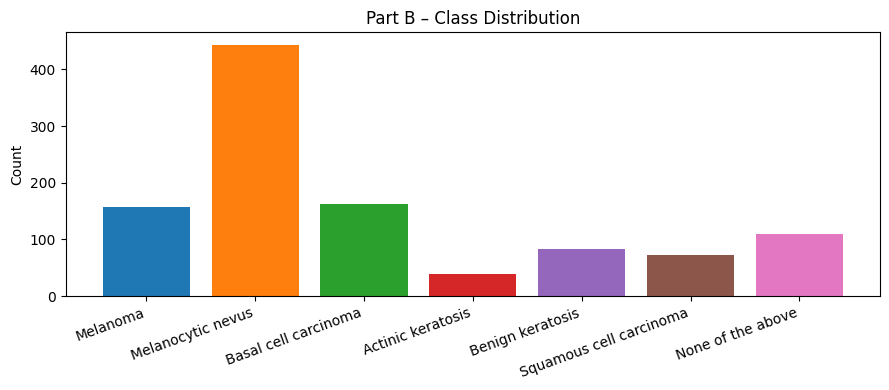

In [32]:
"""TODO: Load the supplement Excel file and map each `iddx_full` entry to one of the 7 class labels.
Merge with the main image DataFrame on `isic_id` — this inner join reduces the working set
to the **1,068 samples** that have a supplement annotation.

Plot the class distribution as a bar chart. Note the imbalance: Melanocytic nevus (~41%)
dominates while Actinic keratosis (~4%) is the rarest named class."""

# YOUR CODE HERE
CLASS_NAMES = [
    "Melanoma", "Melanocytic nevus", "Basal cell carcinoma",
    "Actinic keratosis", "Benign keratosis",
    "Squamous cell carcinoma", "None of the above",
]
NUM_CLASSES = 7
 
def map_class(iddx) -> int:
    if pd.isna(iddx): return 6
    s = str(iddx).lower()
    if "malignant melanocytic proliferations (melanoma)" in s: return 0
    if "benign melanocytic proliferations" in s and "nevus" in s: return 1
    if "basal cell carcinoma" in s: return 2
    if "solar or actinic keratosis" in s or "actinic keratosis" in s: return 3
    if any(k in s for k in ["solar lentigo", "seborrheic keratosis",
                              "lichen planus like keratosis",
                              "pigmented benign keratosis"]): return 4
    if "squamous cell carcinoma" in s: return 5
    return 6
 
supp_df = pd.read_csv(SUPP_XLSX)
supp_df["class_label"] = supp_df["iddx_full"].apply(map_class)
supp_df["img_path"] = supp_df["isic_id"].apply(lambda x: IMAGE_DIR / f"{x}.jpg")
supp_df = supp_df[supp_df["img_path"].apply(lambda p: p.exists())].reset_index(drop=True)
 
print(f"Total labelled samples with images: {len(supp_df)}")
print("\nClass distribution:")
for i, name in enumerate(CLASS_NAMES):
    n = (supp_df["class_label"] == i).sum()
    print(f"  [{i}] {name}: {n}")
 
fig, ax = plt.subplots(figsize=(9, 4))
counts = supp_df["class_label"].value_counts().sort_index()
ax.bar(CLASS_NAMES, [counts.get(i, 0) for i in range(NUM_CLASSES)],
       color=plt.cm.tab10.colors[:NUM_CLASSES])
ax.set_ylabel("Count"); ax.set_title("Part B – Class Distribution")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

## Train / Validation / Test Split  (60 : 20 : 20)

In [33]:
"""TODO: Perform a stratified 60/20/20 split on `class_label` (not `malignant`) so that
every class is proportionally represented in all three folds.

**Transforms:**  
- *Training:* same augmentation pipeline as Part A, with stronger `ColorJitter` and an
  added `RandomPerspective` to improve generalisation on rare classes.  
- *Evaluation:* resize + normalize only (same as Part A).

**Imbalance handling:**  
Compute per-class inverse-frequency weights and pass them to `WeightedRandomSampler`
so that every training batch is approximately class-balanced. The val and test loaders
use no sampler (natural distribution is preserved for unbiased evaluation)."""

# YOUR CODE HERE

from PIL import Image
import torch, torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
 
# From ImageNet normalization statistics
_MEAN = [0.485, 0.456, 0.406]
_STD  = [0.229, 0.224, 0.225]
 
class SkinLesionDatasetB(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["img_path"]).convert("RGB")
        label = torch.tensor(int(row["class_label"]), dtype=torch.long)
        if self.transform: image = self.transform(image)
        return image, label
 
train_transform = T.Compose([
    T.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    T.RandomCrop(IMAGE_SIZE),
    T.RandomHorizontalFlip(), T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    T.RandomRotation(20),
    T.RandomPerspective(distortion_scale=0.2, p=0.3),
    T.ToTensor(), T.Normalize(_MEAN, _STD),
])
eval_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)), T.ToTensor(), T.Normalize(_MEAN, _STD),
])
 
df_train, df_temp = train_test_split(
    supp_df, test_size=(1 - TRAIN_RATIO), stratify=supp_df["class_label"], random_state=SEED)
df_val, df_test = train_test_split(
    df_temp, test_size=0.5, stratify=df_temp["class_label"], random_state=SEED)
 
print(f"Train: {len(df_train)}  Val: {len(df_val)}  Test: {len(df_test)}")
 
# Weighted sampler
class_counts  = np.bincount(df_train["class_label"].values, minlength=NUM_CLASSES).astype(float)
class_counts  = np.where(class_counts == 0, 1, class_counts)
sample_weights = torch.from_numpy((1.0 / class_counts)[df_train["class_label"].values]).double()
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
 
train_loader = DataLoader(SkinLesionDatasetB(df_train, train_transform),
                          batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS)
val_loader   = DataLoader(SkinLesionDatasetB(df_val,   eval_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(SkinLesionDatasetB(df_test,  eval_transform),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print(f"Loaders: train={len(train_loader)} | val={len(val_loader)} | test={len(test_loader)}")

Train: 640  Val: 214  Test: 214
Loaders: train=20 | val=7 | test=7


## Hybrid DenseNet + EfficientNet Model

In [34]:
"""TODO: The architecture is identical to Part A — two parallel CNN branches whose feature vectors
are concatenated (2816-d) and passed through a fusion MLP — with one modification:

- **Output layer:** `nn.Linear(512, 7)` replaces the binary `nn.Linear(512, 1)`
- **Activation:** raw logits are returned (no sigmoid); `softmax` is applied at
  inference time only

Both backbones remain frozen during training (transfer learning from ImageNet weights)."""

# YOUR CODE HERE 
import torch.nn as nn
import torchvision.models as models
 
class HybridDenseNetEfficientNetB(nn.Module):
    _DENSENET_OUT     = 1024
    _EFFICIENTNET_OUT = 1792
 
    def __init__(self, num_classes=NUM_CLASSES, dropout=DROPOUT, freeze_backbones=True):
        super().__init__()
        dn = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        self.densenet_features = dn.features
        self.densenet_pool     = nn.AdaptiveAvgPool2d((1, 1))
 
        en = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.DEFAULT)
        self.efficientnet_features = en.features
        self.efficientnet_pool     = nn.AdaptiveAvgPool2d((1, 1))
 
        if freeze_backbones:
            for p in self.densenet_features.parameters(): p.requires_grad = False
            for p in self.efficientnet_features.parameters(): p.requires_grad = False
 
        combined_dim = self._DENSENET_OUT + self._EFFICIENTNET_OUT
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(combined_dim), nn.Dropout(dropout),
            nn.Linear(combined_dim, 512), nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2), nn.Linear(512, num_classes),
        )
 
    def forward(self, x):
        d = torch.flatten(self.densenet_pool(self.densenet_features(x)), 1)
        e = torch.flatten(self.efficientnet_pool(self.efficientnet_features(x)), 1)
        return self.classifier(torch.cat([d, e], dim=1))
 
model_b = HybridDenseNetEfficientNetB(freeze_backbones=True).to(DEVICE)
n_train = sum(p.numel() for p in model_b.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_train:,}")

Trainable parameters: 1,451,527


## Training Setup

In [35]:
"""TODO: Configure training components for 7-class classification:

- **Loss:** `nn.CrossEntropyLoss` with `weight` set to inverse class frequencies —
  this penalises errors on rare classes (e.g. Actinic keratosis) more heavily than
  errors on dominant classes (e.g. Melanocytic nevus).
- **Optimiser:** AdamW with weight decay (same as Part A).
- **Scheduler:** Cosine annealing LR over all epochs (same as Part A).
- **Scaler:** Mixed-precision `GradScaler` for GPU (same as Part A)."""

# YOUR CODE HERE 
import torch.optim as optim
 
full_counts = np.bincount(supp_df["class_label"].values, minlength=NUM_CLASSES).astype(float)
full_counts = np.where(full_counts == 0, 1, full_counts)
ce_weights  = torch.tensor(1.0 / full_counts, dtype=torch.float32).to(DEVICE)
ce_weights  = ce_weights / ce_weights.sum() * NUM_CLASSES
 
criterion = nn.CrossEntropyLoss(weight=ce_weights)
optimizer = optim.AdamW(model_b.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
scaler    = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))
print("Training setup complete. CE weights:", ce_weights.cpu().numpy().round(3))

Training setup complete. CE weights: [0.593 0.21  0.571 2.386 1.121 1.274 0.846]


## Training Loop

In [36]:
"""TODO: Adapt the `run_epoch` function from Part A for multi-class output:
- Replace `BCEWithLogitsLoss` scoring with `CrossEntropyLoss`
- Replace binary AUC computation with **macro-averaged AUC-ROC** (one-vs-rest,
  using `roc_auc_score(..., multi_class='ovr', average='macro')`)

Train for `NUM_EPOCHS` with early stopping on validation macro-AUC.
Save the best checkpoint to `best_model_partB.pth`."""

"TODO: Adapt the `run_epoch` function from Part A for multi-class output:\n- Replace `BCEWithLogitsLoss` scoring with `CrossEntropyLoss`\n- Replace binary AUC computation with **macro-averaged AUC-ROC** (one-vs-rest,\n  using `roc_auc_score(..., multi_class='ovr', average='macro')`)\n\nTrain for `NUM_EPOCHS` with early stopping on validation macro-AUC.\nSave the best checkpoint to `best_model_partB.pth`."

## (Before Hyperparameter Tuning — Extract Features from the Pretrained Nets)

In [37]:
"""TODO: The frozen DenseNet-121 and EfficientNet-B4 backbones are used to extract feature vectors
for every sample **once** and cache them to disk (`train_feats_b.pt`, `val_feats_b.pt`).

During tuning, each trial loads these cached features instead of re-running images through
the full backbone — this makes each trial significantly faster since only the lightweight
fusion MLP classifier is trained.

> Note: Because Part B has only ~1,068 samples (vs ~401K in Part A), feature extraction
> completes in seconds. The caching step is kept for consistency and to allow more trials
> within the same compute budget."""

from torch.utils.data import Dataset
from tqdm.auto import tqdm
 
def extract_features_B(model, dataloader, device, save_path):
    model.eval()
    all_d, all_e, all_labels = [], [], []
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f"Extracting→{save_path}"):
            images = images.to(device)
            d = torch.flatten(model.densenet_pool(model.densenet_features(images)), 1)
            e = torch.flatten(model.efficientnet_pool(model.efficientnet_features(images)), 1)
            all_d.append(d.cpu()); all_e.append(e.cpu()); all_labels.append(labels.cpu())
    torch.save({"densenet": torch.cat(all_d), "efficientnet": torch.cat(all_e),
                "labels": torch.cat(all_labels)}, save_path)
    print(f"  Saved {torch.cat(all_d).shape[0]} samples → {save_path}")
 
class CachedFeatureDsB(Dataset):
    def __init__(self, path):
        data = torch.load(path, weights_only=True)
        self.fused  = torch.cat([data["densenet"], data["efficientnet"]], dim=1)
        self.labels = data["labels"]
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.fused[idx], self.labels[idx]
 
extract_features_B(model_b, train_loader, DEVICE, "train_feats_b.pt")
extract_features_B(model_b, val_loader,   DEVICE, "val_feats_b.pt")
 
cached_labels = torch.load("train_feats_b.pt", weights_only=True)["labels"].numpy()
cc  = np.bincount(cached_labels, minlength=NUM_CLASSES).astype(float)
cc  = np.where(cc == 0, 1, cc)
sw  = torch.from_numpy((1.0 / cc)[cached_labels]).double()
feat_sampler = WeightedRandomSampler(sw, len(sw), replacement=True)
 
feat_train_loader = DataLoader(CachedFeatureDsB("train_feats_b.pt"), batch_size=256,
                               sampler=feat_sampler, num_workers=NUM_WORKERS)
feat_val_loader   = DataLoader(CachedFeatureDsB("val_feats_b.pt"),   batch_size=256,
                               shuffle=False, num_workers=NUM_WORKERS)
print("Cached loaders ready.")

Extracting→train_feats_b.pt:   0%|          | 0/20 [00:00<?, ?it/s]

  Saved 640 samples → train_feats_b.pt


Extracting→val_feats_b.pt:   0%|          | 0/7 [00:00<?, ?it/s]

  Saved 214 samples → val_feats_b.pt
Cached loaders ready.


## Hyperparameter Tuning

In [38]:
"""TODO: Run `N_TRIALS` random search trials over the hyperparameter grid using `ParameterSampler`.
Each trial trains the **fusion MLP classifier only** (backbones remain frozen) for
`TRIAL_EPOCHS` epochs on the cached features and reports **macro AUC-ROC** on the
validation set.

The search grid covers:
- `LR` — learning rate for AdamW
- `WEIGHT_DECAY` — L2 regularisation strength
- `DROPOUT` — dropout rate in the fusion MLP head

Key differences from Part A's tuning:
- Loss is `CrossEntropyLoss` with **inverse class-frequency weights** (not `BCEWithLogitsLoss`)
- Validation scoring uses `roc_auc_score(..., multi_class='ovr', average='macro')`
  instead of binary AUC
- Due to the small dataset, overfitting within even 3 trial epochs is possible —
  trials with a large train/val AUC gap are considered unreliable regardless of val AUC

After all trials, results are sorted by `val_auc` (descending). The best hyperparameters
are saved to `best_hyperparameters_partB.csv` and used to train the final model in the
**Training Loop** section."""

from sklearn.model_selection import ParameterSampler
from sklearn.metrics import roc_auc_score
 
TRIAL_EPOCHS = 3
N_TRIALS     = 10
param_grid   = {
    "LR":           [5e-4, 1e-3, 5e-3, 1e-2],
    "WEIGHT_DECAY": [1e-4, 1e-3, 1e-2],
    "DROPOUT":      [0.2, 0.3, 0.4, 0.5],
}
param_list = list(ParameterSampler(param_grid, n_iter=N_TRIALS, random_state=SEED))
 
def run_epoch_B(model, loader, criterion, optimizer=None, scaler=None,
                device=DEVICE, desc="", use_cached=False):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_labels, all_probs = 0.0, [], []
    with torch.set_grad_enabled(is_train):
        for images, labels in tqdm(loader, desc=desc, leave=False):
            images, labels = images.to(device), labels.to(device)
            with torch.amp.autocast(device.type, enabled=(device.type == "cuda")):
                logits = model.classifier(images) if use_cached else model(images)
                loss = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad(); scaler.scale(loss).backward()
                scaler.step(optimizer); scaler.update()
            total_loss += loss.item() * images.size(0)
            probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
            all_probs.extend(probs); all_labels.extend(labels.cpu().numpy())
    all_labels, all_probs = np.array(all_labels), np.array(all_probs)
    present = np.unique(all_labels)
    try:
        auc = roc_auc_score(all_labels, all_probs[:, present],
                            multi_class="ovr", average="macro", labels=present) \
              if len(present) > 1 else float("nan")
    except Exception: auc = float("nan")
    return total_loss / len(loader.dataset), auc
 
def run_trial_B(params):
    m    = HybridDenseNetEfficientNetB(dropout=params["DROPOUT"],
                                       freeze_backbones=True).to(DEVICE)
    crit = nn.CrossEntropyLoss(weight=ce_weights)
    opt  = optim.AdamW(m.classifier.parameters(),
                       lr=params["LR"], weight_decay=params["WEIGHT_DECAY"])
    sch  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=TRIAL_EPOCHS, eta_min=1e-6)
    sc   = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))
    best = 0.0
    for ep in range(TRIAL_EPOCHS):
        run_epoch_B(m, feat_train_loader, crit, opt, sc,
                    desc=f"  ep{ep+1}", use_cached=True)
        sch.step()
        _, v_auc = run_epoch_B(m, feat_val_loader, crit,
                               desc=f"  val{ep+1}", use_cached=True)
        if not np.isnan(v_auc): best = max(best, v_auc)
    return best
 
tuning_results = []
for i, params in enumerate(param_list):
    auc = run_trial_B(params)
    tuning_results.append({"params": params, "val_auc": auc})
    print(f"Trial {i+1:>2}/{N_TRIALS} | AUC={auc:.4f} | {params}")
 
tuning_results.sort(key=lambda x: x["val_auc"], reverse=True)
best_params = tuning_results[0]["params"]
pd.DataFrame([{**r["params"], "val_auc": r["val_auc"]} for r in tuning_results]) \
  .to_csv("best_hyperparameters_partB.csv", index=False)
print(f"Best params: {best_params}")

  ep1:   0%|          | 0/3 [00:00<?, ?it/s]

  val1:   0%|          | 0/1 [00:00<?, ?it/s]

  ep2:   0%|          | 0/3 [00:00<?, ?it/s]

  val2:   0%|          | 0/1 [00:00<?, ?it/s]

  ep3:   0%|          | 0/3 [00:00<?, ?it/s]

...

  ep2:   0%|          | 0/3 [00:00<?, ?it/s]

  val2:   0%|          | 0/1 [00:00<?, ?it/s]

  ep3:   0%|          | 0/3 [00:00<?, ?it/s]

  val3:   0%|          | 0/1 [00:00<?, ?it/s]

Trial 10/10 | AUC=0.7179 | {'WEIGHT_DECAY': 0.0001, 'LR': 0.001, 'DROPOUT': 0.4}
Best params: {'WEIGHT_DECAY': 0.01, 'LR': 0.005, 'DROPOUT': 0.5}


## Training Curves

Train [1]:   0%|          | 0/3 [00:00<?, ?it/s]

Val   [1]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch   1 | tr_loss=2.2098 tr_auc=0.6507 | vl_loss=1.8275 vl_auc=0.7333 *best*


Train [2]:   0%|          | 0/3 [00:00<?, ?it/s]

Val   [2]:   0%|          | 0/1 [00:00<?, ?it/s]

...

Val   [3]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch   3 | tr_loss=1.0527 tr_auc=0.9051 | vl_loss=1.9264 vl_auc=0.6826 (patience 2/3)


Train [4]:   0%|          | 0/3 [00:00<?, ?it/s]

Val   [4]:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch   4 | tr_loss=0.9287 tr_auc=0.9180 | vl_loss=1.9925 vl_auc=0.6891 (patience 3/3)
Early stopping.
Best val AUC: 0.7333  checkpoint: best_model_partB.pth


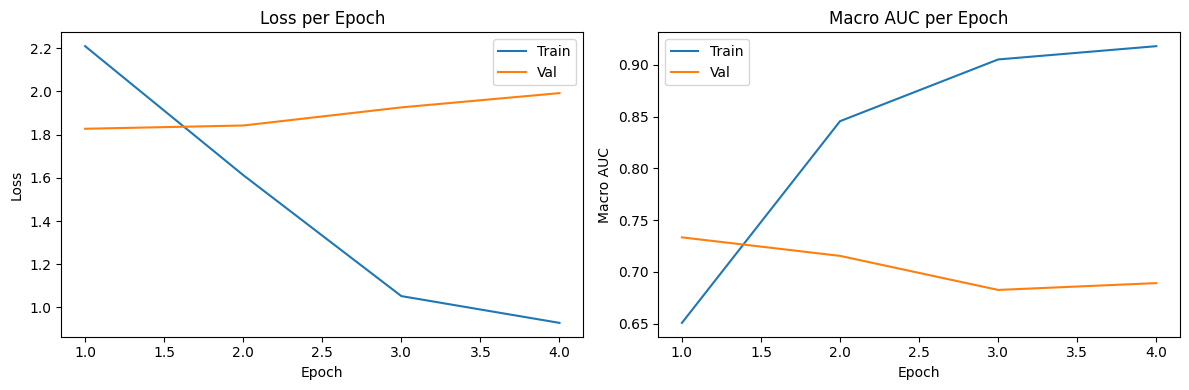

In [ ]:
"""TODO: Plot train vs. validation **loss** and **macro AUC-ROC** per epoch (2-panel figure).
A widening gap between train and val curves indicates overfitting — expected given the
small dataset size (~641 training samples)."""

model_b   = HybridDenseNetEfficientNetB(dropout=best_params["DROPOUT"],
                                        freeze_backbones=True).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=ce_weights)
optimizer = optim.AdamW(model_b.classifier.parameters(),
                        lr=best_params["LR"], weight_decay=best_params["WEIGHT_DECAY"])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
scaler    = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))
 
PATIENCE  = 3  
CKPT_PATH_B = "best_model_partB.pth"
history   = {"train_loss": [], "train_auc": [], "val_loss": [], "val_auc": []}
best_val_auc, patience_ctr = 0.0, 0
 
for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_auc = run_epoch_B(model_b, feat_train_loader, criterion, optimizer,
                                  scaler, desc=f"Train [{epoch}]", use_cached=True)
    vl_loss, vl_auc = run_epoch_B(model_b, feat_val_loader, criterion,
                                  desc=f"Val   [{epoch}]", use_cached=True)
    scheduler.step()
    history["train_loss"].append(tr_loss); history["train_auc"].append(tr_auc)
    history["val_loss"].append(vl_loss);  history["val_auc"].append(vl_auc)
    if (not np.isnan(vl_auc)) and vl_auc > best_val_auc:
        best_val_auc = vl_auc; patience_ctr = 0
        torch.save(model_b.state_dict(), CKPT_PATH_B); tag = " *best*"
    else:
        patience_ctr += 1; tag = f" (patience {patience_ctr}/{PATIENCE})"
    print(f"Epoch {epoch:>3} | tr_loss={tr_loss:.4f} tr_auc={tr_auc:.4f} | "
          f"vl_loss={vl_loss:.4f} vl_auc={vl_auc:.4f}{tag}")
    if patience_ctr >= PATIENCE:
        print("Early stopping."); break
 
print(f"Best val AUC: {best_val_auc:.4f}  checkpoint: {CKPT_PATH_B}")


epochs_ran = range(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs_ran, history["train_loss"], label="Train")
ax1.plot(epochs_ran, history["val_loss"],   label="Val")
ax1.set(xlabel="Epoch", ylabel="Loss", title="Loss per Epoch"); ax1.legend()
ax2.plot(epochs_ran, history["train_auc"], label="Train")
ax2.plot(epochs_ran, history["val_auc"],   label="Val")
ax2.set(xlabel="Epoch", ylabel="Macro AUC", title="Macro AUC per Epoch"); ax2.legend()
plt.tight_layout(); plt.show()

## Evaluation on Test Set

Extracting→test_feats_b.pt:   0%|          | 0/7 [00:00<?, ?it/s]

  Saved 214 samples → test_feats_b.pt
PART B TEST RESULTS
  Macro AUC-ROC : 0.6745
  Macro F1      : 0.2204
  Accuracy      : 0.3551
                         precision    recall  f1-score   support

               Melanoma       0.21      0.12      0.16        32
      Melanocytic nevus       0.58      0.52      0.55        89
   Basal cell carcinoma       0.34      0.47      0.39        32
      Actinic keratosis       0.00      0.00      0.00         8
       Benign keratosis       0.08      0.12      0.10        16
Squamous cell carcinoma       0.24      0.60      0.35        15
      None of the above       0.00      0.00      0.00        22

               accuracy                           0.36       214
              macro avg       0.21      0.26      0.22       214
           weighted avg       0.35      0.36      0.34       214



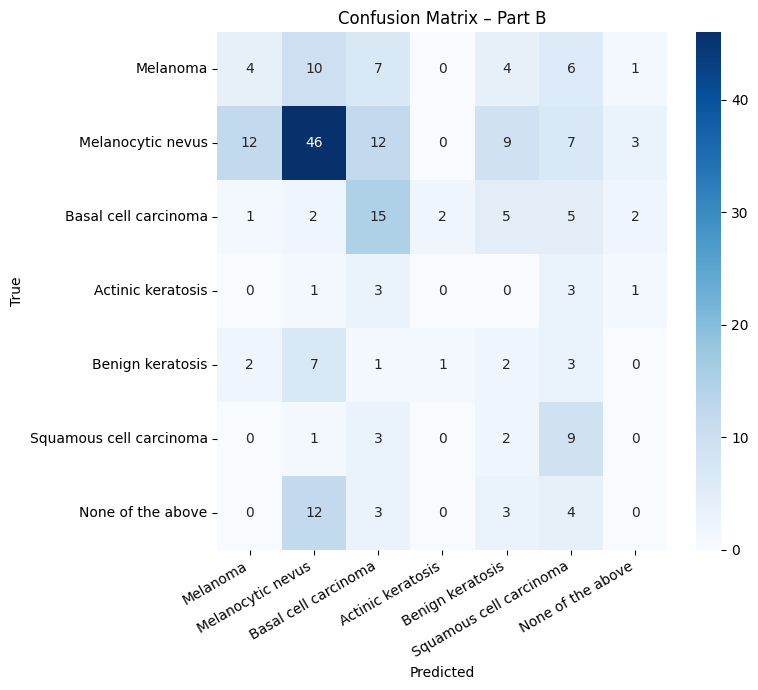

In [40]:
"""TODO: Load the best checkpoint and evaluate on the held-out test set.

Report the following metrics:
- **Macro AUC-ROC** (one-vs-rest) — primary metric; weights all 7 classes equally
- **Macro F1-score** — penalises both false positives and false negatives per class
- **Per-class classification report** — precision, recall, F1, and support for each
  of the 7 categories

Also produce a **confusion matrix** heatmap to identify which classes are most
frequently confused with each other."""

from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import seaborn as sns, os
 
extract_features_B(model_b, test_loader, DEVICE, "test_feats_b.pt")
feat_test_loader = DataLoader(CachedFeatureDsB("test_feats_b.pt"), batch_size=256,
                              shuffle=False, num_workers=NUM_WORKERS)
 
if os.path.exists(CKPT_PATH_B):
    model_b.load_state_dict(torch.load(CKPT_PATH_B, map_location=DEVICE, weights_only=True))
model_b.eval()
 
all_labels, all_probs = [], []
with torch.no_grad():
    for feats, labels in feat_test_loader:
        probs = torch.softmax(model_b.classifier(feats.to(DEVICE)), dim=1).cpu().numpy()
        all_probs.extend(probs); all_labels.extend(labels.numpy())
all_labels, all_probs = np.array(all_labels), np.array(all_probs)
all_preds  = np.argmax(all_probs, axis=1)
present    = np.unique(all_labels)
 
try:
    test_auc = roc_auc_score(all_labels, all_probs[:, present],
                             multi_class="ovr", average="macro", labels=present)
except Exception as e:
    test_auc = float("nan"); print(f"AUC warn: {e}")
test_f1  = f1_score(all_labels, all_preds, average="macro", zero_division=0)
test_acc = accuracy_score(all_labels, all_preds)
pnames   = [CLASS_NAMES[i] for i in present]
 
print("="*55, "\nPART B TEST RESULTS")
print(f"  Macro AUC-ROC : {test_auc:.4f}")
print(f"  Macro F1      : {test_f1:.4f}")
print(f"  Accuracy      : {test_acc:.4f}")
print("="*55)
print(classification_report(all_labels, all_preds, labels=present,
                            target_names=pnames, zero_division=0))
 
cm = confusion_matrix(all_labels, all_preds, labels=present)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=pnames, yticklabels=pnames, ax=ax)
ax.set(ylabel="True", xlabel="Predicted", title="Confusion Matrix – Part B")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()